**O. Import des bibliothèques**

In [1]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation des données
import matplotlib.pyplot as plt
import seaborn as sns

# Importation du jeu de données Linnerud
from sklearn.datasets import load_linnerud

# Prétraitement des données
from sklearn.model_selection import train_test_split, cross_val_score

# Normalisation des données
from sklearn.preprocessing import StandardScaler

# Modélisation des données
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**1. Chargement du dataset**

In [ ]:
linnerud = load_linnerud(as_frame=True)

df = linnerud.frame

X = linnerud.data
y = linnerud.target

print(df.head())

   Chins  Situps  Jumps  Weight  Waist  Pulse
0    5.0   162.0   60.0   191.0   36.0   50.0
1    2.0   110.0   60.0   189.0   37.0   52.0
2   12.0   101.0  101.0   193.0   38.0   58.0
3   12.0   105.0   37.0   162.0   35.0   62.0
4   13.0   155.0   58.0   189.0   35.0   46.0
(20, 6)


**2. Compréhension générale des données**

In [4]:
# Afficher les dimensions du DataFrame
print(df.shape)

(20, 6)


In [3]:
# Vérifier rapidement les variables

print("Variables explicatives :")
print(X.columns.tolist())

print("\nVariables cibles :")
print(y.columns.tolist())

Variables explicatives :
['Chins', 'Situps', 'Jumps']

Variables cibles :
['Weight', 'Waist', 'Pulse']


On a donc le problème suivant : Peut-on prédire simultanément le poids, le tour de taille et le pouls d'une personne à partir de ses performances physiques ?

[Chins, Situps, Jumps]→[Weight, Waist, Pulse]

In [5]:
# Vérifier les infos sur le DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Chins   20 non-null     float64
 1   Situps  20 non-null     float64
 2   Jumps   20 non-null     float64
 3   Weight  20 non-null     float64
 4   Waist   20 non-null     float64
 5   Pulse   20 non-null     float64
dtypes: float64(6)
memory usage: 1.1 KB


In [6]:
# Afficher les stats descriptives du DataFrame
df.describe()

,Chins,Situps,Jumps,Weight,Waist,Pulse
count,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000
mean,9.450000,145.550000,70.30000,178.600000,35.400000,56.100000
std,5.286278,62.566575,51.27747,24.690505,3.201973,7.210373
min,1.000000,50.000000,25.00000,138.000000,31.000000,46.000000
25%,4.750000,101.000000,39.50000,160.750000,33.000000,51.500000
50%,11.500000,122.500000,54.00000,176.000000,35.000000,55.000000
75%,13.250000,210.000000,85.25000,191.500000,37.000000,60.500000
max,17.000000,251.000000,250.00000,247.000000,46.000000,74.000000


In [7]:
# Vérifier les valeurs manquantes
df.isnull().sum()

Chins     0
Situps    0
Jumps     0
Weight    0
Waist     0
Pulse     0
dtype: int64

In [9]:
# Y a-t-il des doublons ?
df.duplicated().sum()

np.int64(0)

**3. Exploration et analyse des données (EDA)**

**3.1. Analyse Univariée**

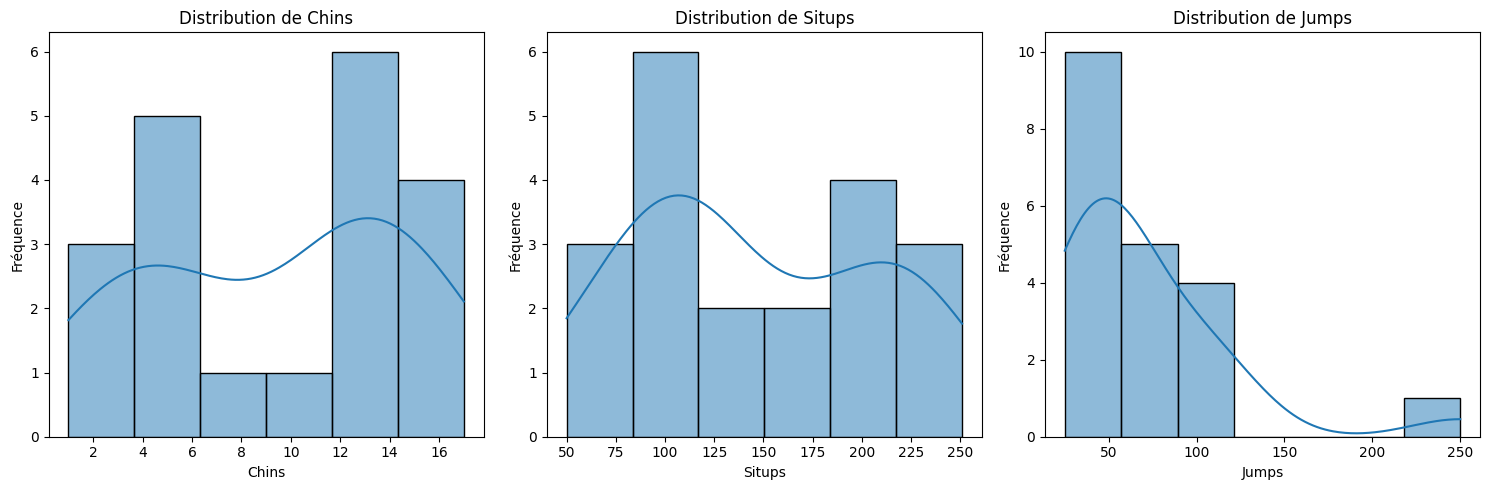

In [ ]:
# Visualisation des distributions des variables explicatives
features = ['Chins', 'Situps', 'Jumps']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, features):
    sns.histplot(df[feature], kde=True, ax=ax)
    ax.set_title(f'Distribution de {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

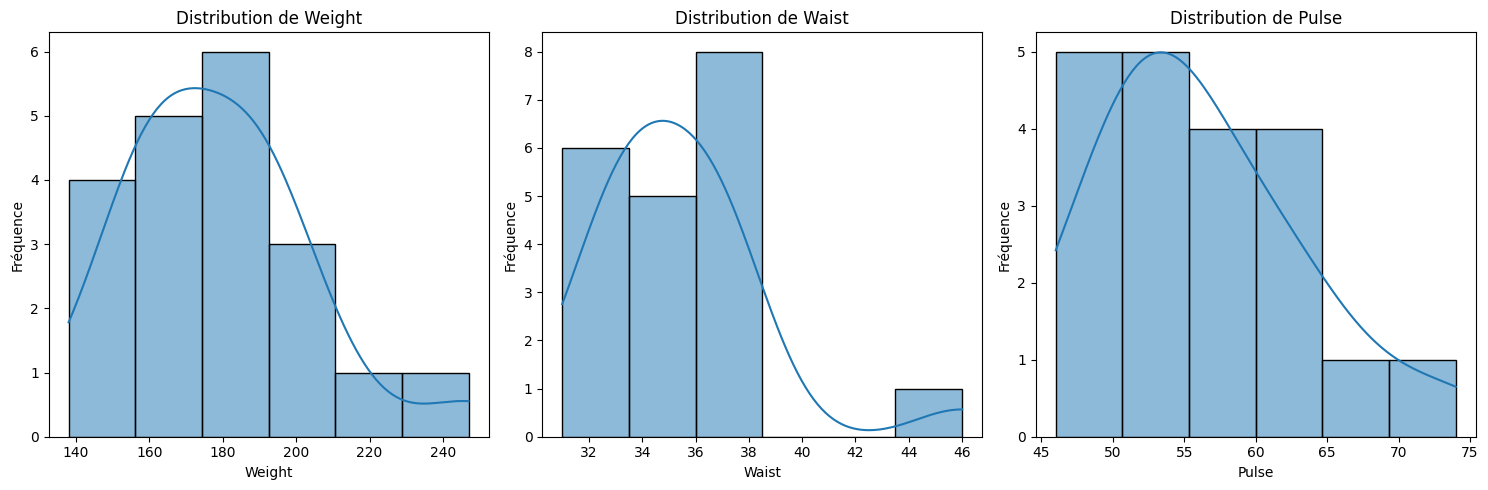

In [11]:
# Visualisation des distributions des variables cibles
targets = ['Weight', 'Waist', 'Pulse']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, target in zip(axes, targets):
    sns.histplot(df[target], kde=True, ax=ax)
    ax.set_title(f'Distribution de {target}')
    ax.set_xlabel(target)
    ax.set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

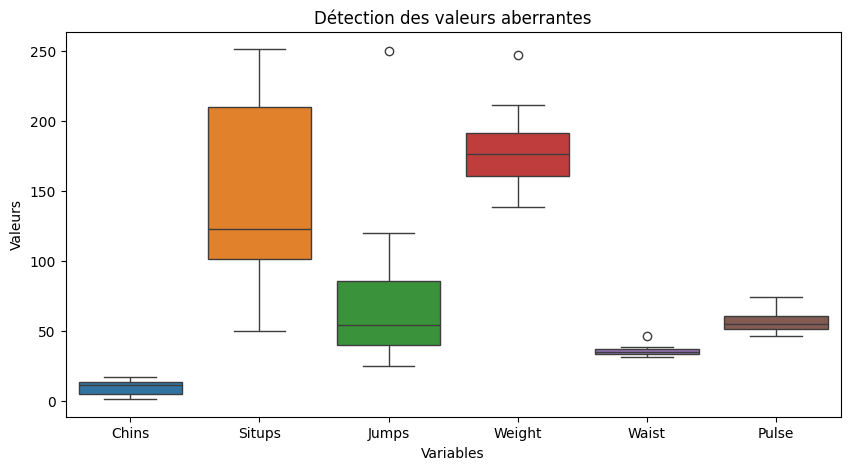

In [12]:
# Détection des valeurs aberrantes avec un boxplot
plt.figure(figsize=(10, 5))

sns.boxplot(data=df)

plt.title("Détection des valeurs aberrantes")
plt.xlabel("Variables")
plt.ylabel("Valeurs")

plt.show()

**3.2 Analyse bivariée**

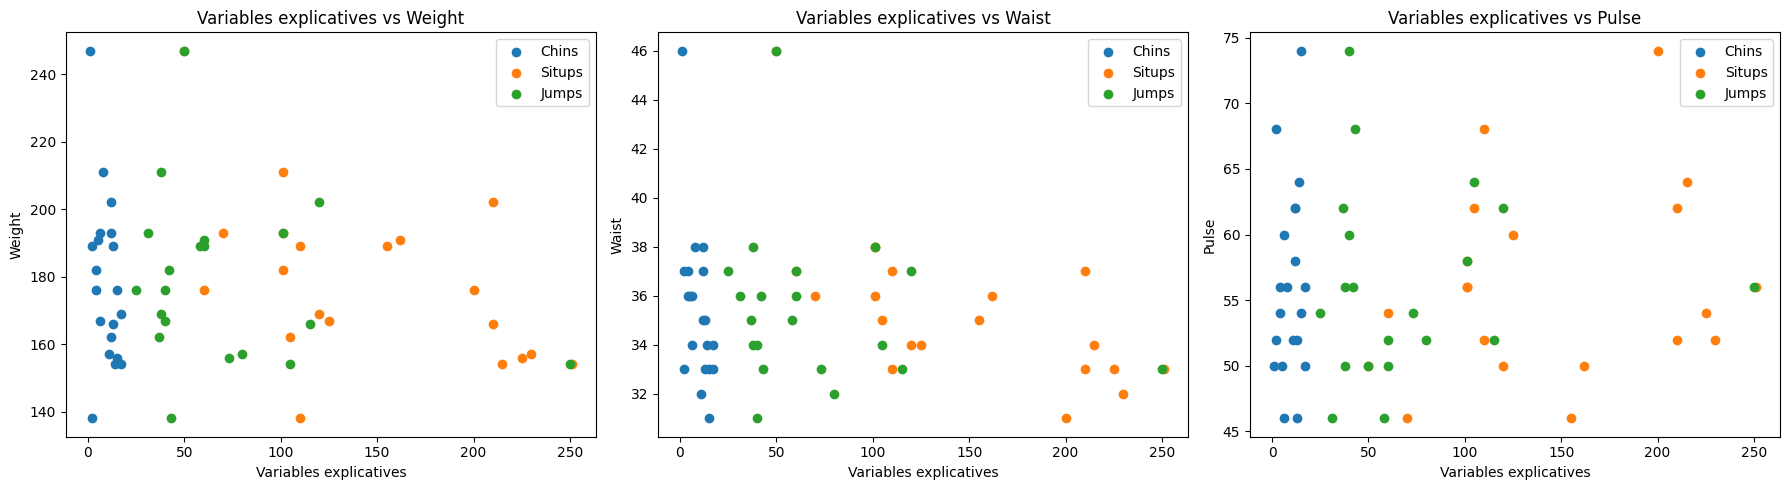

In [ ]:
# Visualisation des relations entre les variables explicatives et les variables cibles par une matrice de nuages de points
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes, targets):
    for feature in features:
        ax.scatter(df[feature], df[target], label=feature)

    ax.set_title(f"Variables explicatives vs {target}")
    ax.set_xlabel("Variables explicatives")
    ax.set_ylabel(target)
    ax.legend()

plt.tight_layout()
plt.show()

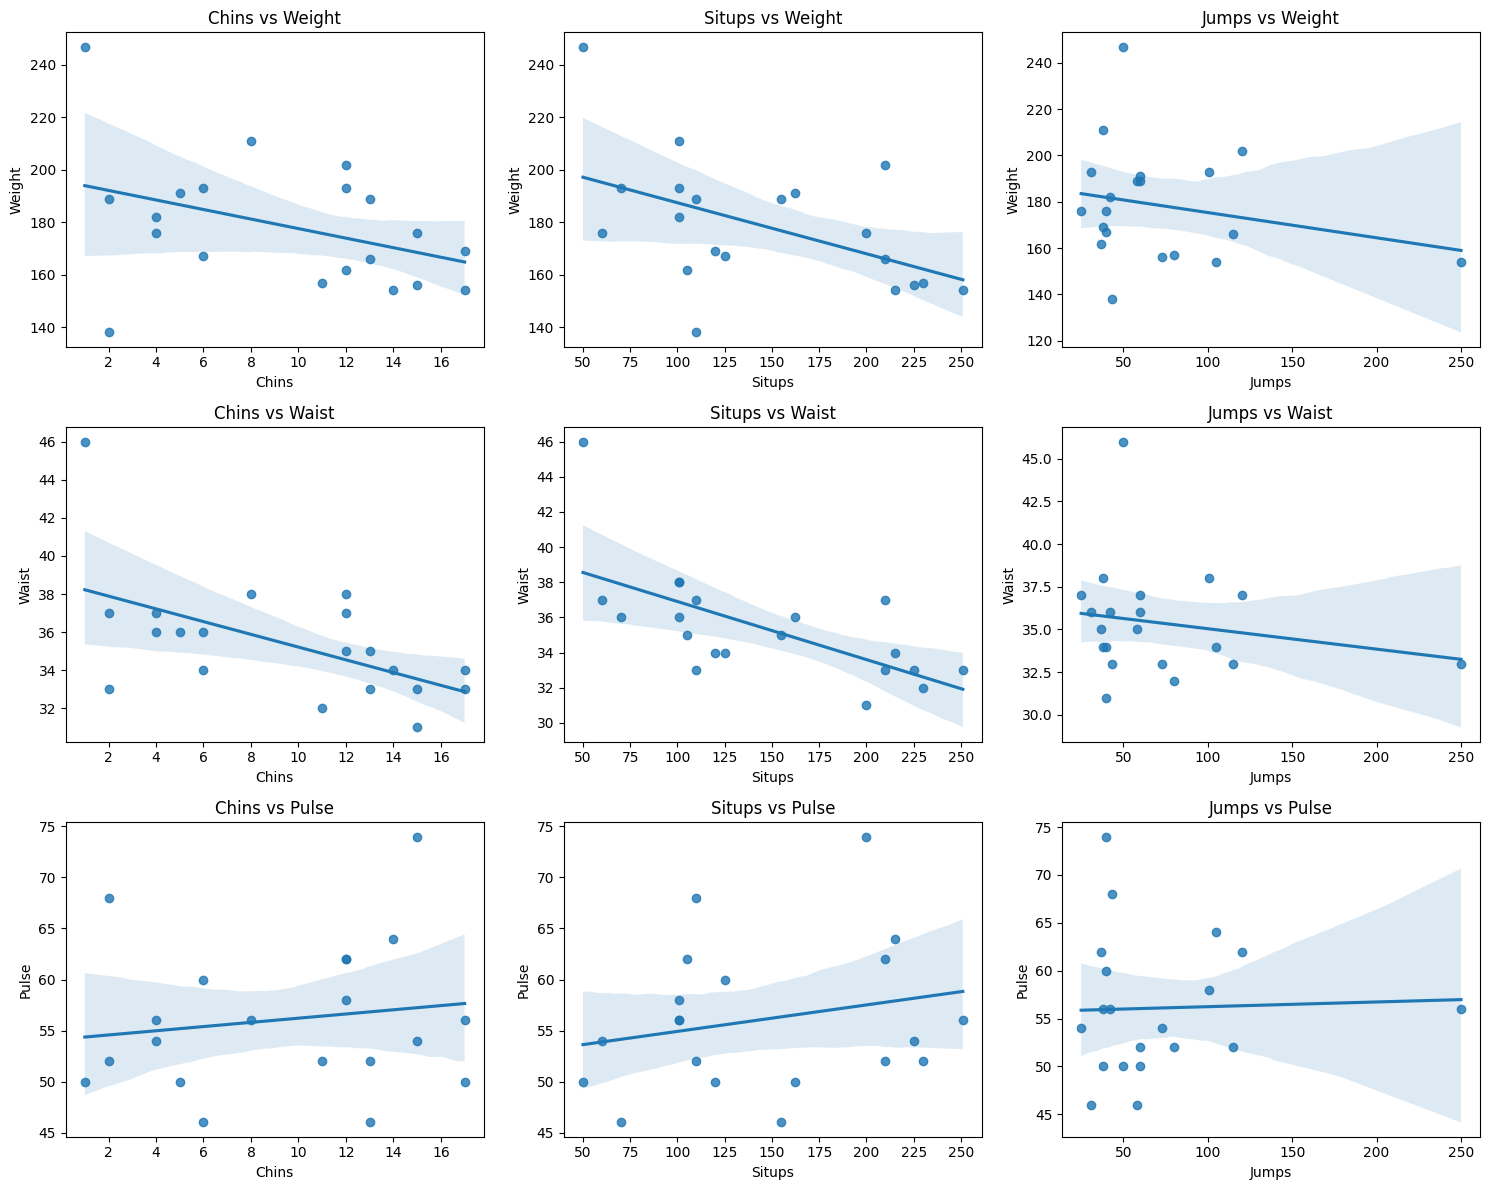

In [15]:
# Visualisation des relations entre les variables par paire
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, target in enumerate(targets):
    for j, feature in enumerate(features):
        sns.regplot(
            data=df,
            x=feature,
            y=target,
            ax=axes[i, j]
        )
        axes[i, j].set_title(f'{feature} vs {target}')

plt.tight_layout()
plt.show()

In [16]:
# Calculer la matrice de corrélation
correlation = df.corr()

print(correlation)

           Chins    Situps     Jumps    Weight     Waist     Pulse
Chins   1.000000  0.695727  0.495760 -0.389694 -0.552232  0.150648
Situps  0.695727  1.000000  0.669206 -0.493084 -0.645598  0.225038
Jumps   0.495760  0.669206  1.000000 -0.226296 -0.191499  0.034933
Weight -0.389694 -0.493084 -0.226296  1.000000  0.870243 -0.365762
Waist  -0.552232 -0.645598 -0.191499  0.870243  1.000000 -0.352892
Pulse   0.150648  0.225038  0.034933 -0.365762 -0.352892  1.000000


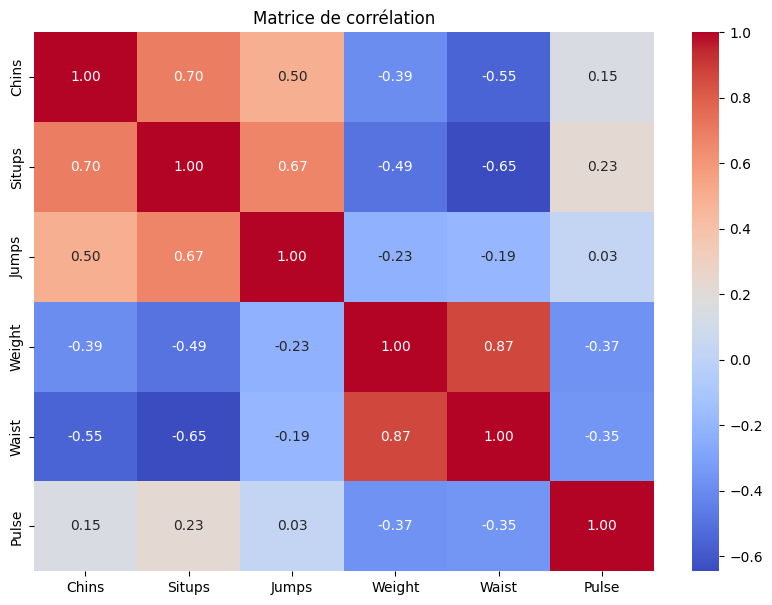

In [17]:
# Visualisation des corrélations avec une heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Matrice de corrélation")

plt.show()


**4. Définition du problème de Machine Learning**

**5. Préparation des données**

**6. Modélisation**

**7. Validation et évaluation des modèles**

**8. Sélection du meilleur modèle**

**10. Analyse et interprétation des résultats**

**12. Perspectives**